# SAM + CLIP

In [1]:
!pip install torch opencv-python Pillow
!pip install git+https://github.com/openai/CLIP.git
!pip install git+https://github.com/facebookresearch/sam2.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 97.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir -p ../checkpoints/
!wget -P ../checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt

--2025-03-16 13:14:28--  https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 108.157.254.124, 108.157.254.102, 108.157.254.121, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|108.157.254.124|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 898083611 (856M) [application/vnd.snesdev-page-table]
Saving to: ‘../checkpoints/sam2.1_hiera_large.pt’

sam2.1_hiera_large. 100%[===================>] 856.48M   275MB/s    in 3.1s    

2025-03-16 13:14:31 (275 MB/s) - ‘../checkpoints/sam2.1_hiera_large.pt’ saved [898083611/898083611]



In [3]:
import cv2
import torch
import numpy as np
from PIL import Image, ImageDraw

import clip
from sam2.build_sam import build_sam2
from sam2.automatic_mask_generator import SAM2AutomaticMaskGenerator

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
def convert_box_xywh_to_xyxy(box):
    x1 = box[0]
    y1 = box[1]
    x2 = box[0] + box[2]
    y2 = box[1] + box[3]
    return [x1, y1, x2, y2]

In [6]:
def segment_image(image_array, segmentation_mask):

    segmented_image_array = np.zeros_like(image_array)
    segmented_image_array[segmentation_mask] = image_array[segmentation_mask]
    segmented_image = Image.fromarray(segmented_image_array)

    image_size = (image_array.shape[1], image_array.shape[0])
    black_image = Image.new("RGB", image_size, (0, 0, 0))

    transparency_mask = np.zeros_like(segmentation_mask, dtype=np.uint8)
    transparency_mask[segmentation_mask] = 255
    transparency_mask_image = Image.fromarray(transparency_mask, mode='L')

    black_image.paste(segmented_image, mask=transparency_mask_image)

    return black_image

In [7]:
# sam_checkpoint = "/content/drive/MyDrive/URP/checkpoints/sam2.1_hiera_base_plus.pt"
# model_cfg = "/content/drive/MyDrive/URP/sam2.1_hiera_b+.yaml"
sam2_checkpoint = "../checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

sam2 = build_sam2(model_cfg, sam2_checkpoint, device=device, apply_postprocessing=False)
mask_generator = SAM2AutomaticMaskGenerator(
    model=sam2,
    # points_per_side=64,
    # points_per_batch=128,
    # pred_iou_thresh=0.7,
    # stability_score_thresh=0.92,
    # stability_score_offset=0.7,
    # crop_n_layers=1,
    # box_nms_thresh=0.7,
    # crop_n_points_downscale_factor=2,
    # min_mask_region_area=25.0,
    # use_m2m=True,
    )

model, preprocess = clip.load("ViT-B/32", device=device)

100%|████████████████████████████████████████| 338M/338M [00:00<00:00, 413MiB/s]


In [8]:
image_path = "/content/drive/MyDrive/URP/images/truck.jpg"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

masks = mask_generator.generate(image)

cropped_boxes = []

for mask in masks:
    cropped_boxes.append(segment_image(image, mask["segmentation"]).crop(convert_box_xywh_to_xyxy(mask["bbox"])))

In [9]:
@torch.no_grad()
def retriev(elements: list[Image.Image], search_text: str) -> int:

    preprocessed_images = [preprocess(image).to(device) for image in elements]

    tokenized_text = clip.tokenize([search_text]).to(device)

    stacked_images = torch.stack(preprocessed_images)

    image_features = model.encode_image(stacked_images)
    text_features = model.encode_text(tokenized_text)

    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)

    probs = 100. * image_features @ text_features.T
    probs.sort(dim=1, descending=True)

    return probs[:, 0].softmax(dim=0)

In [10]:
# @torch.no_grad()
# def retriev(elements: list[Image.Image], search_text: str) -> int:

#     preprocessed_images = [preprocess(image).to(device) for image in elements]

#     tokenized_text = clip.tokenize([search_text]).to(device)

#     image_features = model.encode_image(preprocessed_images)
#     text_features = model.encode_text(tokenized_text)

#     logits_per_image, logits_per_text = model(preprocessed_images, search_text)
#     probs = logits_per_image.softmax(dim=-1).cpu().numpy()

#     # image_features /= image_features.norm(dim=-1, keepdim=True)
#     # text_features /= text_features.norm(dim=-1, keepdim=True)

#     # probs = 100. * image_features @ text_features.T
#     # probs.sort(dim=1, descending=True)

#     return probs[:,0]
#     # probs[:, 0].softmax(dim=0)

In [11]:
def get_indices_of_values_above_threshold(values, threshold):
    return [i for i, v in enumerate(values) if v > threshold]

In [12]:
text_prompt = "truck"
# text_prompt = "blue car"

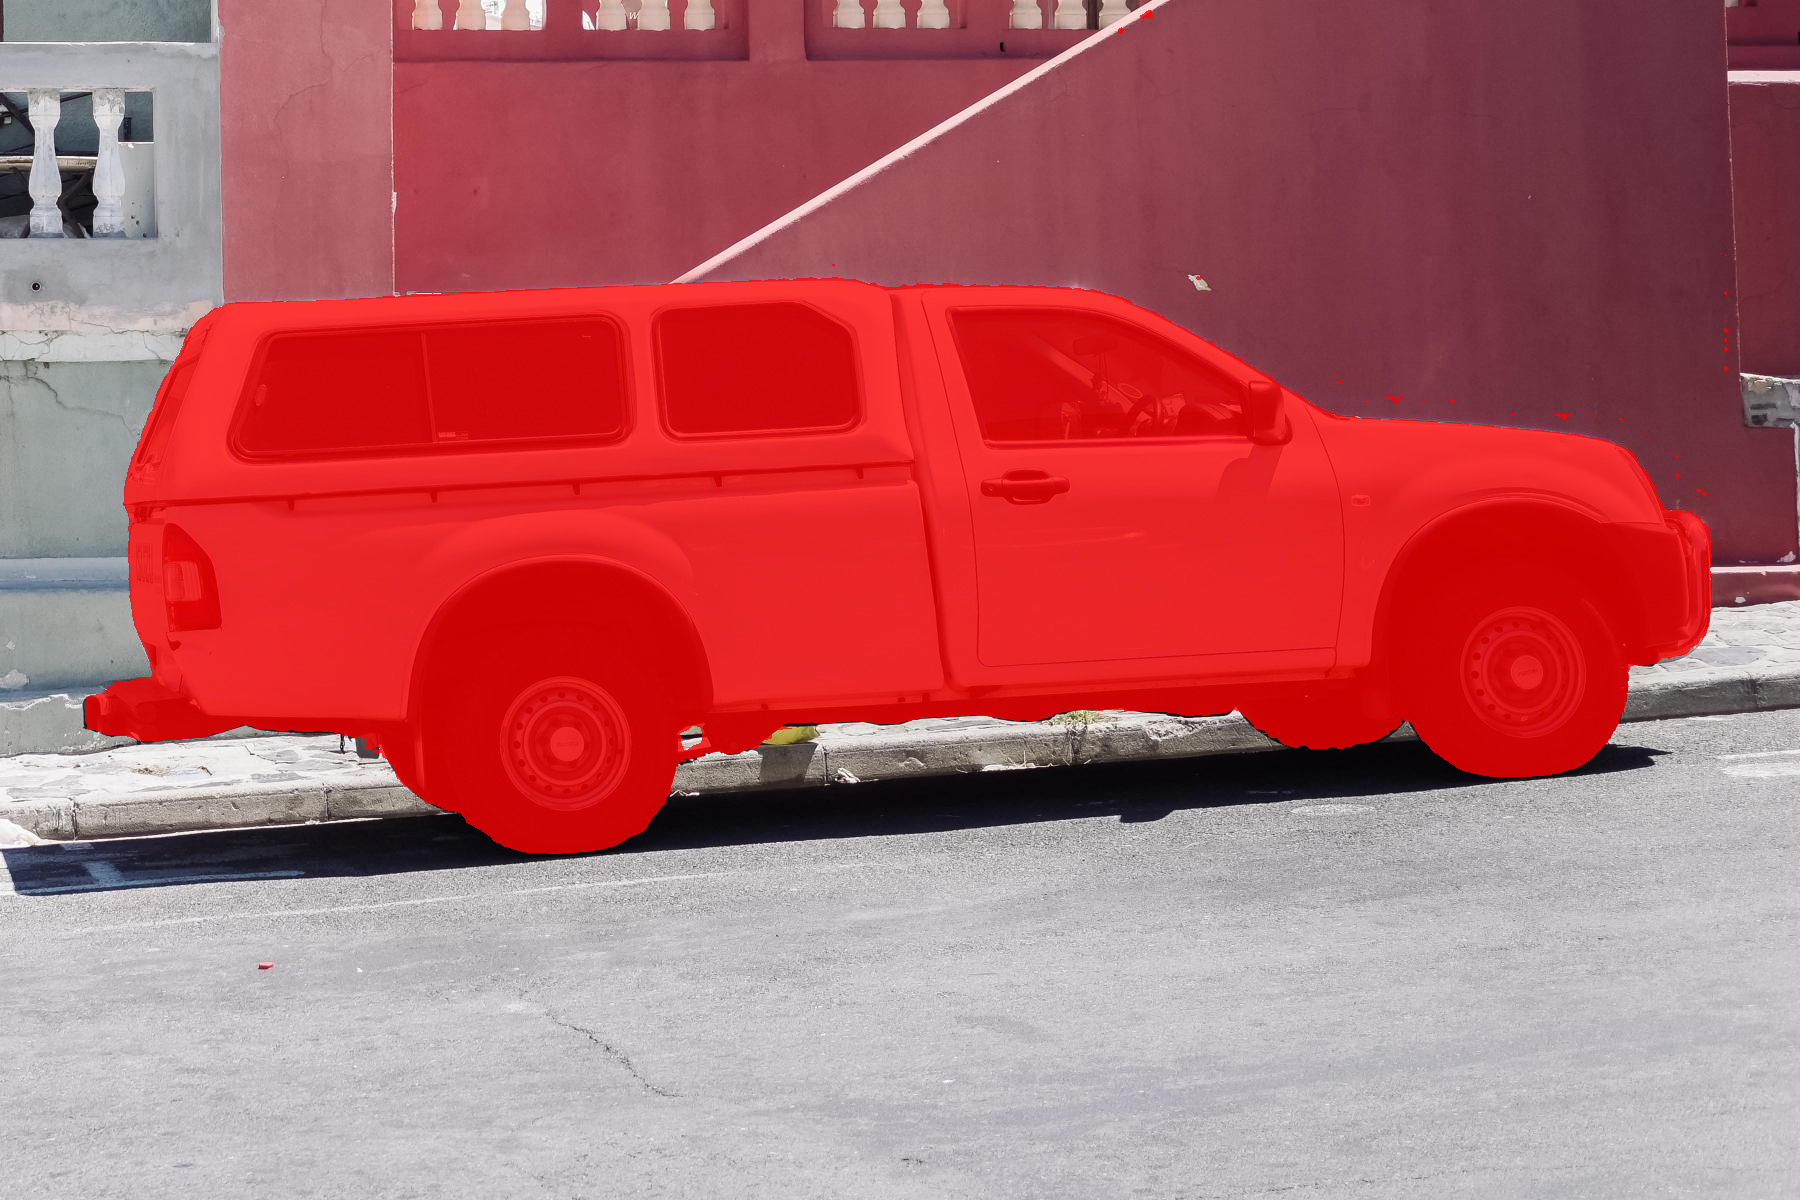

In [14]:
scores = retriev(cropped_boxes, text_prompt)
indices = get_indices_of_values_above_threshold(scores, 0.05)

segmentation_masks = []

for seg_idx in indices:
    segmentation_mask_image = Image.fromarray(masks[seg_idx]["segmentation"].astype('uint8') * 255)
    segmentation_masks.append(segmentation_mask_image)

original_image = Image.open(image_path)
overlay_image = Image.new('RGBA', original_image.size, (0, 0, 0, 0))
overlay_color = (255, 0, 0, 200)

draw = ImageDraw.Draw(overlay_image)
for segmentation_mask_image in segmentation_masks:
    draw.bitmap((0, 0), segmentation_mask_image, fill=overlay_color)

result_image = Image.alpha_composite(original_image.convert('RGBA'), overlay_image)
result_image.save("/content/drive/MyDrive/URP/result/truck.png")
result_image